# IMDB 영화 리뷰 감성분석 LSTM — TensorFlow/Keras 변환 코드

목표는 영화 리뷰 문장을 입력받아 해당 리뷰가 **부정 리뷰인지 긍정 리뷰인지 분류하는 이진 분류 모델**을 만드는 것입니다.

전체 구성은 다음과 같습니다.

1. 실행 환경 확인
2. 라이브러리 불러오기
3. 하이퍼파라미터 설정
4. IMDB 데이터 준비
5. 리뷰 길이 맞추기
6. 단어 사전 확인과 리뷰 복원
7. TensorFlow Dataset 구성
8. TensorFlow/Keras LSTM 모델 설계
9. 손실 함수와 최적화 알고리즘 설정
10. 모델 학습
11. 모델 평가
12. 손실과 정확도 시각화
13. 혼동행렬과 F1 점수 확인
14. 샘플 리뷰 예측
15. 모델 저장과 불러오기


## 1. 라이브러리 불러오기

아래 코드는 데이터 처리, 모델 생성, 학습, 평가, 시각화에 필요한 라이브러리를 불러옵니다.


In [1]:
# os는 운영체제 관련 기능을 사용할 때 필요한 표준 라이브러리입니다.
# 여기서는 파일 저장 경로를 다룰 때 사용할 수 있습니다.
import os

# time은 학습 시간을 측정하기 위해 사용하는 표준 라이브러리입니다.
# 학습 시작 시간과 종료 시간을 기록하여 전체 학습 시간을 계산합니다.
from time import time

# numpy는 숫자 배열을 효율적으로 처리하는 라이브러리입니다.
# 모델 예측 결과, 정답 배열, 혼동행렬 처리 등에 사용합니다.
import numpy as np

# matplotlib.pyplot은 그래프를 그리는 라이브러리입니다.
# 학습 손실, 정확도, 혼동행렬 시각화에 사용합니다.
import matplotlib.pyplot as plt

# confusion_matrix는 실제 라벨과 예측 라벨을 비교하여 혼동행렬을 계산합니다.
from sklearn.metrics import confusion_matrix

# f1_score는 정밀도와 재현율을 함께 고려한 F1 점수를 계산합니다.
from sklearn.metrics import f1_score

# accuracy_score는 실제 라벨과 예측 라벨을 비교하여 정확도를 계산합니다.
from sklearn.metrics import accuracy_score

# tensorflow는 딥러닝 모델 생성, 학습, 평가를 수행하는 대표적인 라이브러리입니다.
import tensorflow as tf

# keras는 TensorFlow 안에서 신경망 모델을 쉽게 만들 수 있게 해주는 고수준 API입니다.
from tensorflow import keras

# layers는 Embedding, LSTM, Dense, Dropout 같은 신경망 계층을 만들 때 사용합니다.
from tensorflow.keras import layers

# imdb는 TensorFlow/Keras에서 제공하는 IMDB 영화 리뷰 데이터셋 로더입니다.
from tensorflow.keras.datasets import imdb

# pad_sequences는 길이가 서로 다른 리뷰 문장을 같은 길이로 맞추기 위해 사용합니다.
from tensorflow.keras.preprocessing.sequence import pad_sequences

# numpy 출력 옵션을 설정합니다.
# suppress=True는 아주 작은 값이 과학적 표기법으로 과도하게 표시되는 것을 줄여줍니다.
np.set_printoptions(precision=3, suppress=True)

# 현재 TensorFlow 버전을 출력하여 실행 환경을 확인합니다.
print("TensorFlow version:", tf.__version__)

# 현재 TensorFlow에서 인식하는 GPU 장치 목록을 출력합니다.
# GPU가 표시되면 학습이 더 빠르게 실행될 수 있습니다.
print("사용 가능한 GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
사용 가능한 GPU: []


## 2. 하이퍼파라미터 설정

하이퍼파라미터는 모델이 학습으로 자동으로 찾는 값이 아니라, 사람이 학습 전에 직접 정하는 설정값입니다.

이 예제에서는 리뷰 문장을 숫자 시퀀스로 바꾸고, LSTM이 단어 순서를 학습하도록 구성합니다.


In [2]:
# 실험 결과를 최대한 비슷하게 재현하기 위해 난수 시드를 고정합니다.
SEED = 111

# numpy 난수 시드를 고정합니다.
# 데이터 처리 과정에서 난수가 사용될 경우 같은 결과가 나오도록 돕습니다.
np.random.seed(SEED)

# TensorFlow 난수 시드를 고정합니다.
# 모델 초기 가중치와 학습 과정의 난수성을 어느 정도 고정할 수 있습니다.
tf.random.set_seed(SEED)

# 사용할 최대 단어 개수입니다.
# IMDB 데이터에서 가장 자주 등장하는 상위 10000개 단어만 사용합니다.
NUM_WORDS = 10000

# 각 영화 리뷰의 최대 길이입니다.
# 길이가 80보다 긴 리뷰는 잘라내고, 짧은 리뷰는 0으로 채워 길이를 맞춥니다.
MAX_LEN = 80

# 단어 하나를 몇 차원 벡터로 표현할지 정합니다.
# 예를 들어 EMBED_DIM=30이면 단어 하나가 30개 숫자로 구성된 벡터가 됩니다.
EMBED_DIM = 30

# LSTM 은닉 상태의 차원 수입니다.
# 값이 클수록 더 복잡한 문장 패턴을 표현할 수 있지만 학습 시간이 길어지고 과적합 위험도 커집니다.
HIDDEN_DIM = 100

# LSTM 계층 수입니다.
# 이 TensorFlow 기본 변환 코드에서는 1개 LSTM 계층을 사용합니다.
NUM_LAYERS = 1

# 학습 반복 횟수입니다.
# 전체 학습 데이터를 처음부터 끝까지 한 번 학습하는 과정을 1 epoch라고 합니다.
EPOCHS = 10

# 한 번에 모델에 입력할 리뷰 개수입니다.
# 배치 크기가 너무 크면 메모리를 많이 사용하고, 너무 작으면 학습이 불안정할 수 있습니다.
BATCH_SIZE = 128

# 학습률입니다.
# 모델 가중치를 한 번 업데이트할 때 얼마나 크게 수정할지 결정합니다.
LEARNING_RATE = 0.001

# Dropout 비율입니다.
# 학습 중 일부 뉴런을 무작위로 비활성화하여 과적합을 줄이는 데 사용합니다.
DROPOUT = 0.3

# AdamW에서 사용할 가중치 감쇠 값입니다.
# 가중치가 지나치게 커지는 것을 막아 과적합을 줄이는 데 도움을 줍니다.
WEIGHT_DECAY = 1e-4

# 설정값을 출력하여 현재 실습 조건을 확인합니다.
print("SEED:", SEED)
print("NUM_WORDS:", NUM_WORDS)
print("MAX_LEN:", MAX_LEN)
print("EMBED_DIM:", EMBED_DIM)
print("HIDDEN_DIM:", HIDDEN_DIM)
print("NUM_LAYERS:", NUM_LAYERS)
print("EPOCHS:", EPOCHS)
print("BATCH_SIZE:", BATCH_SIZE)
print("LEARNING_RATE:", LEARNING_RATE)
print("DROPOUT:", DROPOUT)
print("WEIGHT_DECAY:", WEIGHT_DECAY)


SEED: 111
NUM_WORDS: 10000
MAX_LEN: 80
EMBED_DIM: 30
HIDDEN_DIM: 100
NUM_LAYERS: 1
EPOCHS: 10
BATCH_SIZE: 128
LEARNING_RATE: 0.001
DROPOUT: 0.3
WEIGHT_DECAY: 0.0001


## 3. 데이터 준비

IMDB 영화 리뷰 데이터셋은 영화 리뷰 문장과 감성 라벨로 구성됩니다.

- 입력 데이터: 단어가 숫자로 바뀐 리뷰 문장
- 출력 데이터: 감성 라벨
  - `0`: 부정 리뷰
  - `1`: 긍정 리뷰

리뷰마다 길이가 다르므로 LSTM에 넣기 전에 같은 길이로 맞춥니다.


In [3]:
# IMDB 데이터셋을 불러옵니다.
# num_words=NUM_WORDS는 가장 자주 등장하는 상위 NUM_WORDS개 단어만 사용한다는 의미입니다.
# 반환값은 학습 데이터와 평가 데이터로 나뉘어 있습니다.
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

# 원본 학습 입력 데이터의 모양을 출력합니다.
# IMDB 원본 데이터는 리뷰마다 길이가 달라 dtype=object 형태로 저장됩니다.
print("학습용 입력 데이터 모양:", X_train.shape)

# 원본 학습 정답 데이터의 모양을 출력합니다.
print("학습용 정답 데이터 모양:", y_train.shape)

# 원본 평가 입력 데이터의 모양을 출력합니다.
print("평가용 입력 데이터 모양:", X_test.shape)

# 원본 평가 정답 데이터의 모양을 출력합니다.
print("평가용 정답 데이터 모양:", y_test.shape)

# 첫 번째 리뷰의 숫자 시퀀스를 출력합니다.
# 각 숫자는 단어 사전에 등록된 특정 단어 번호를 의미합니다.
print("\n첫 번째 영화 리뷰 숫자 시퀀스:")
print(X_train[0])

# 첫 번째 리뷰의 단어 개수를 출력합니다.
# 아직 길이 맞추기 전이므로 리뷰마다 길이가 서로 다를 수 있습니다.
print("첫 번째 리뷰 단어 수:", len(X_train[0]))

# 첫 번째 리뷰의 정답 라벨을 출력합니다.
# 0은 부정, 1은 긍정을 의미합니다.
print("첫 번째 리뷰 감성 라벨:", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
학습용 입력 데이터 모양: (25000,)
학습용 정답 데이터 모양: (25000,)
평가용 입력 데이터 모양: (25000,)
평가용 정답 데이터 모양: (25000,)

첫 번째 영화 리뷰 숫자 시퀀스:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92,

In [4]:
# 첫 10개 리뷰의 길이를 출력하는 함수를 정의합니다.
def show_review_lengths(data, title):
    # 출력 제목을 표시합니다.
    print(title)

    # 앞에서부터 10개 리뷰를 확인합니다.
    for i in range(10):
        # i번째 리뷰의 길이를 출력합니다.
        # 길이 맞추기 전에는 리뷰마다 단어 개수가 다르게 출력될 수 있습니다.
        print(f"리뷰 {i}: {len(data[i])}개 단어")

# 길이 정리 전 학습 데이터의 리뷰 길이를 확인합니다.
show_review_lengths(X_train, "\n길이 정리 전 첫 10개 리뷰 길이")



길이 정리 전 첫 10개 리뷰 길이
리뷰 0: 218개 단어
리뷰 1: 189개 단어
리뷰 2: 141개 단어
리뷰 3: 550개 단어
리뷰 4: 147개 단어
리뷰 5: 43개 단어
리뷰 6: 123개 단어
리뷰 7: 562개 단어
리뷰 8: 233개 단어
리뷰 9: 130개 단어


## 4. 리뷰 길이 맞추기

LSTM은 배치 단위로 학습할 때 입력 길이가 동일해야 합니다.  
따라서 모든 리뷰 길이를 `MAX_LEN`으로 맞춥니다.


In [5]:
# 리뷰 길이를 MAX_LEN으로 통일합니다.
# truncating="post"는 길이가 긴 리뷰의 뒤쪽 단어를 잘라낸다는 의미입니다.
# padding="post"는 길이가 짧은 리뷰의 뒤쪽에 0을 채운다는 의미입니다.
X_train = pad_sequences(
    X_train,                 # 길이를 맞출 학습 리뷰 데이터입니다.
    maxlen=MAX_LEN,          # 모든 리뷰를 MAX_LEN 길이로 맞춥니다.
    truncating="post",       # 긴 리뷰는 뒤쪽을 잘라냅니다.
    padding="post"           # 짧은 리뷰는 뒤쪽에 0을 채웁니다.
)

# 평가 데이터도 학습 데이터와 같은 방식으로 길이를 맞춥니다.
X_test = pad_sequences(
    X_test,                  # 길이를 맞출 평가 리뷰 데이터입니다.
    maxlen=MAX_LEN,          # 모든 리뷰를 MAX_LEN 길이로 맞춥니다.
    truncating="post",       # 긴 리뷰는 뒤쪽을 잘라냅니다.
    padding="post"           # 짧은 리뷰는 뒤쪽에 0을 채웁니다.
)

# TensorFlow 모델 학습에 적합하도록 입력 데이터를 int32 자료형으로 변환합니다.
# Embedding 계층은 정수 단어 번호를 입력으로 받습니다.
X_train = X_train.astype("int32")
X_test = X_test.astype("int32")

# 정답 라벨을 float32 자료형으로 변환합니다.
# binary_crossentropy는 0.0 또는 1.0 형태의 실수 라벨을 사용할 수 있습니다.
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# 길이 정리 후 학습 데이터의 리뷰 길이를 확인합니다.
show_review_lengths(X_train, "\n길이 정리 후 첫 10개 리뷰 길이")

# 길이 정리 후 최종 데이터 모양을 출력합니다.
print("\n학습 입력 최종 모양:", X_train.shape)
print("평가 입력 최종 모양:", X_test.shape)

# 정답 데이터 모양도 출력합니다.
print("학습 정답 최종 모양:", y_train.shape)
print("평가 정답 최종 모양:", y_test.shape)



길이 정리 후 첫 10개 리뷰 길이
리뷰 0: 80개 단어
리뷰 1: 80개 단어
리뷰 2: 80개 단어
리뷰 3: 80개 단어
리뷰 4: 80개 단어
리뷰 5: 80개 단어
리뷰 6: 80개 단어
리뷰 7: 80개 단어
리뷰 8: 80개 단어
리뷰 9: 80개 단어

학습 입력 최종 모양: (25000, 80)
평가 입력 최종 모양: (25000, 80)
학습 정답 최종 모양: (25000,)
평가 정답 최종 모양: (25000,)


## 5. 단어 사전 확인과 리뷰 문장 복원

IMDB 데이터셋의 리뷰는 실제 단어가 아니라 숫자로 저장되어 있습니다.

숫자 시퀀스를 사람이 읽기 쉬운 단어로 되돌려 보면 데이터 구조를 이해하는 데 도움이 됩니다.


In [6]:
# 단어를 숫자로 바꿔주는 원본 사전을 불러옵니다.
# 예를 들어 "good"이라는 단어가 특정 숫자 번호에 연결되어 있습니다.
word_to_id = imdb.get_word_index()

# 숫자를 단어로 바꿔주는 반대 사전을 만듭니다.
# 원래 사전이 {단어: 번호} 형태이므로 {번호: 단어} 형태로 뒤집습니다.
id_to_word = {value: key for key, value in word_to_id.items()}

# 전체 단어 사전 크기를 출력합니다.
print("전체 단어 사전 크기:", len(word_to_id))

# 특정 단어가 몇 번째 번호인지 확인합니다.
print("단어 'virus'의 번호:", word_to_id.get("virus"))

# 특정 번호가 어떤 단어인지 확인합니다.
print("3310번 단어:", id_to_word.get(3310))


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
전체 단어 사전 크기: 88584
단어 'virus'의 번호: 3310
3310번 단어: virus


In [7]:
# 숫자로 된 리뷰를 단어로 복원하는 함수를 정의합니다.
def decode_review(encoded_review, id_to_word):
    # 복원된 단어들을 저장할 리스트를 만듭니다.
    decoded_words = []

    # 리뷰 안의 숫자 토큰을 하나씩 반복합니다.
    for token_id in encoded_review:
        # 0은 패딩 값이므로 <PAD>로 표시합니다.
        if token_id == 0:
            decoded_words.append("<PAD>")
        else:
            # IMDB 데이터셋은 특수 토큰 때문에 실제 단어 인덱스와 약간 차이가 있습니다.
            # 일반적으로 token_id - 3을 사용하면 원래 단어에 더 가깝게 복원됩니다.
            decoded_words.append(id_to_word.get(int(token_id) - 3, "???"))

    # 단어 리스트를 공백으로 연결하여 하나의 문자열로 반환합니다.
    return " ".join(decoded_words)

# 첫 번째 학습 리뷰를 단어 형태로 복원합니다.
decoded_text = decode_review(X_train[0], id_to_word)

# 복원된 리뷰를 출력합니다.
print("첫 번째 리뷰 복원 결과:")
print(decoded_text)

# 첫 번째 리뷰의 정답 라벨을 출력합니다.
print("\n정답 라벨:", y_train[0], "(0=부정, 1=긍정)")


첫 번째 리뷰 복원 결과:
??? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ??? is an amazing actor and now the same being director ??? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as

정답 라벨: 1.0 (0=부정, 1=긍정)


## 6. TensorFlow Dataset 구성

TensorFlow/Keras는 numpy 배열을 `model.fit()`에 직접 넣을 수도 있습니다.  
하지만 여기서는 PyTorch의 DataLoader와 비슷한 역할을 하는 `tf.data.Dataset`을 사용합니다.

`tf.data.Dataset`을 사용하면 데이터를 배치 단위로 나누고, 학습 중 데이터를 효율적으로 공급할 수 있습니다.


In [8]:
# 학습용 TensorFlow Dataset을 생성합니다.
# from_tensor_slices는 X_train과 y_train을 샘플 단위로 묶어줍니다.
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# shuffle은 학습 데이터 순서를 섞어 모델이 데이터 순서에 과하게 의존하지 않도록 합니다.
# buffer_size는 섞을 때 사용할 데이터 범위를 의미합니다.
train_dataset = train_dataset.shuffle(buffer_size=len(X_train), seed=SEED)

# batch는 데이터를 BATCH_SIZE개씩 묶어 미니배치를 만듭니다.
# 미니배치 단위로 학습하면 전체 데이터를 한 번에 학습하는 것보다 메모리를 적게 사용합니다.
train_dataset = train_dataset.batch(BATCH_SIZE)

# prefetch는 학습 중 다음 배치를 미리 준비하여 학습 속도를 높이는 기능입니다.
# AUTOTUNE은 TensorFlow가 적절한 값을 자동으로 선택하게 합니다.
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# 평가용 TensorFlow Dataset을 생성합니다.
# 평가 데이터는 섞지 않습니다. 섞지 않아도 평가 결과에는 영향이 없습니다.
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# 평가 데이터도 학습과 같은 배치 크기로 묶습니다.
test_dataset = test_dataset.batch(BATCH_SIZE)

# 평가 데이터도 미리 준비할 수 있도록 prefetch를 적용합니다.
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

# 학습 데이터셋에서 첫 번째 배치를 하나 꺼냅니다.
sample_batch_texts, sample_batch_labels = next(iter(train_dataset))

# 배치 입력 모양을 출력합니다.
# 모양은 [배치크기, 문장길이]입니다.
print("배치 입력 모양:", sample_batch_texts.shape)

# 배치 정답 모양을 출력합니다.
# 모양은 [배치크기]입니다.
print("배치 정답 모양:", sample_batch_labels.shape)

# 첫 번째 배치의 라벨 일부를 출력합니다.
print("배치 라벨 일부:", sample_batch_labels[:10].numpy())


배치 입력 모양: (128, 80)
배치 정답 모양: (128,)
배치 라벨 일부: [1. 0. 1. 1. 0. 0. 0. 1. 0. 0.]


## 7. 모델 설계 상세 설명

이 모델은 영화 리뷰 문장의 순서 정보를 학습하기 위해 LSTM을 사용합니다.

### 7.1 입력 데이터 구조

각 리뷰는 단어가 숫자로 바뀐 시퀀스입니다.  
배치로 묶이면 입력 모양은 `[배치크기, 문장길이]`입니다.  
이 노트북에서는 문장 길이를 `80`으로 맞춥니다.

### 7.2 Embedding 계층

숫자 자체에는 단어의 의미가 들어 있지 않습니다.  
`Embedding` 계층은 각 단어 번호를 의미를 가진 벡터로 바꿉니다.  
입력 모양이 `[128, 80]`이면 임베딩 후 모양은 `[128, 80, 30]`입니다.

### 7.3 LSTM 계층

LSTM은 순서가 있는 데이터를 처리하는 순환 신경망 구조입니다.  
리뷰 문장은 단어 순서에 따라 의미가 달라질 수 있으므로 LSTM이 적합합니다.

### 7.4 Dropout 계층

Dropout은 학습 중 일부 뉴런을 무작위로 꺼서 과적합을 줄입니다.

### 7.5 출력층

이 문제는 긍정/부정을 구분하는 이진 분류입니다.  
출력층은 숫자 1개를 출력합니다.  
TensorFlow/Keras에서는 마지막 Dense 계층에 `sigmoid`를 적용하여 긍정 클래스 확률을 바로 출력합니다.


In [9]:
# TensorFlow/Keras의 Sequential API를 사용하여 LSTM 감성분석 모델을 정의합니다.
# Sequential은 계층을 순서대로 쌓는 가장 간단한 모델 생성 방식입니다.
model = keras.Sequential([
    # Input 계층은 모델이 받을 입력 데이터의 모양을 정의합니다.
    # 리뷰 하나는 MAX_LEN개의 단어 번호로 구성되므로 입력 shape은 (MAX_LEN,)입니다.
    layers.Input(shape=(MAX_LEN,)),

    # Embedding 계층은 정수 단어 번호를 밀집 벡터로 변환합니다.
    # input_dim=NUM_WORDS는 단어 사전 크기를 의미합니다.
    # output_dim=EMBED_DIM은 단어 하나를 EMBED_DIM차원 벡터로 표현한다는 의미입니다.
    # mask_zero=True는 패딩 값 0을 실제 단어가 아닌 값으로 처리하도록 알려줍니다.
    layers.Embedding(
        input_dim=NUM_WORDS,
        output_dim=EMBED_DIM,
        mask_zero=True
    ),

    # LSTM 계층은 단어 순서 정보를 학습합니다.
    # units=HIDDEN_DIM은 LSTM이 출력할 은닉 벡터 크기를 의미합니다.
    # return_sequences=False는 모든 시점의 출력을 반환하지 않고 마지막 출력만 반환한다는 뜻입니다.
    layers.LSTM(
        units=HIDDEN_DIM,
        return_sequences=False
    ),

    # Dropout 계층은 학습 중 일부 뉴런을 무작위로 비활성화하여 과적합을 줄입니다.
    layers.Dropout(rate=DROPOUT),

    # Dense 출력층은 LSTM이 만든 문장 표현을 긍정 확률 1개로 변환합니다.
    # sigmoid는 출력값을 0과 1 사이 확률값으로 바꿉니다.
    layers.Dense(
        units=1,
        activation="sigmoid"
    )
])

# 모델 구조를 출력합니다.
# 각 계층의 출력 모양과 학습 가능한 파라미터 수를 확인할 수 있습니다.
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 30)         │       300,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        52,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,501 (1.34 MB)

 Trainable params: 352,501 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

## 8. 손실 함수와 최적화 알고리즘 상세 설명

### 8.1 손실 함수: Binary Crossentropy

이 문제는 영화 리뷰가 긍정인지 부정인지 예측하는 이진 분류 문제입니다.  
따라서 손실 함수로 `binary_crossentropy`를 사용합니다.

모델 마지막 계층에서 `sigmoid`를 사용했기 때문에 모델 출력은 이미 0과 1 사이의 확률입니다.  
그래서 `BinaryCrossentropy(from_logits=False)` 형태로 사용합니다.

### 8.2 예측 기준

모델 출력은 긍정 클래스일 확률입니다.  
확률이 `0.5` 이상이면 긍정(`1`), 미만이면 부정(`0`)으로 분류합니다.

### 8.3 최적화 알고리즘: AdamW

최적화 알고리즘은 손실값을 줄이도록 모델 가중치를 업데이트합니다.  
이 노트북에서는 PyTorch 원본 코드와 같은 계열인 `AdamW`를 사용합니다.

`AdamW`는 Adam 계열 최적화 방법으로, 파라미터별 학습률을 적응적으로 조절하고 가중치 감쇠를 안정적으로 적용하여 과적합 완화에 도움을 줍니다.


In [10]:
# AdamW 최적화 알고리즘을 생성합니다.
# learning_rate는 가중치를 한 번 업데이트할 때 얼마나 크게 움직일지 정합니다.
# weight_decay는 가중치가 지나치게 커지는 것을 막아 과적합을 줄이는 데 도움을 줍니다.
optimizer = keras.optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# 이진 분류 손실 함수를 생성합니다.
# from_logits=False는 모델 출력이 sigmoid를 거친 확률값이라는 뜻입니다.
loss_function = keras.losses.BinaryCrossentropy(from_logits=False)

# 정확도 지표를 생성합니다.
# BinaryAccuracy는 예측 확률을 threshold=0.5 기준으로 0 또는 1로 바꾼 뒤 정확도를 계산합니다.
binary_accuracy = keras.metrics.BinaryAccuracy(threshold=0.5)

# 모델의 학습 방식을 compile로 설정합니다.
# Keras에서는 compile 단계에서 optimizer, loss, metrics를 연결합니다.
model.compile(
    optimizer=optimizer,          # 손실을 줄이기 위해 사용할 최적화 알고리즘입니다.
    loss=loss_function,           # 예측값과 실제값의 차이를 계산할 손실 함수입니다.
    metrics=[binary_accuracy]     # 학습 중 함께 확인할 평가 지표입니다.
)

# 설정된 손실 함수와 최적화 알고리즘을 출력합니다.
print("손실 함수:", loss_function)
print("최적화 알고리즘:", optimizer)


손실 함수: <LossFunctionWrapper(<function binary_crossentropy at 0x7ec8da480fe0>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>
최적화 알고리즘: <keras.src.optimizers.adamw.AdamW object at 0x7ec8c29407a0>


## 9. 모델 학습

TensorFlow/Keras에서는 `model.fit()`을 사용하여 학습합니다.

내부적으로 다음 과정이 반복됩니다.

1. 리뷰 데이터를 모델에 입력합니다.
2. 모델이 긍정 클래스 확률을 출력합니다.
3. 손실 함수가 예측 확률과 정답 라벨을 비교합니다.
4. 역전파로 기울기를 계산합니다.
5. AdamW가 모델 가중치를 업데이트합니다.


In [11]:
# 학습 시작 시간을 기록합니다.
start_time = time()

# 학습 시작 메시지를 출력합니다.
print("학습 시작")

# model.fit은 Keras 모델을 학습시키는 대표 메서드입니다.
# validation_data를 지정하면 각 epoch마다 평가 데이터 성능도 함께 계산합니다.
history = model.fit(
    train_dataset,              # 미니배치 단위로 구성된 학습 데이터셋입니다.
    validation_data=test_dataset, # 각 epoch마다 성능을 확인할 평가 데이터셋입니다.
    epochs=EPOCHS,              # 전체 학습 데이터를 몇 번 반복해서 학습할지 지정합니다.
    verbose=1                   # epoch별 학습 로그를 출력합니다.
)

# 학습 종료 시간을 기록합니다.
end_time = time()

# 전체 학습 시간을 출력합니다.
print(f"\n총 학습 시간: {end_time - start_time:.1f}초")

# history 객체 안에 저장된 기록 이름을 출력합니다.
print("학습 기록 키:", history.history.keys())


학습 시작
Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 29s 139ms/step - binary_accuracy: 0.7269 - loss: 0.5200 - val_binary_accuracy: 0.7949 - val_loss: 0.4603
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - binary_accuracy: 0.8534 - loss: 0.3508 - val_binary_accuracy: 0.7963 - val_loss: 0.4450
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 31s 158ms/step - binary_accuracy: 0.8851 - loss: 0.2913 - val_binary_accuracy: 0.7887 - val_loss: 0.4729
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - binary_accuracy: 0.9000 - loss: 0.2609 - val_binary_accuracy: 0.7870 - val_loss: 0.4850
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 143ms/step - binary_accuracy: 0.9135 - loss: 0.2322 - val_binary_accuracy: 0.7770 - val_loss: 0.5771
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 41s 141ms/step - binary_accuracy: 0.9228 - loss: 0.2086 - val_binary_accuracy: 0.7798 - val_loss: 0.5807
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step - binary_accuracy: 0.9388 - loss: 0.1686 - val_binary_accuracy: 0.776

## 10. 학습 과정 시각화

손실과 정확도 변화를 그래프로 확인하면 모델이 제대로 학습되는지 판단할 수 있습니다.

- 학습 손실이 감소하면 학습 데이터에 대한 오차가 줄고 있다는 뜻입니다.
- 평가 손실이 계속 증가하면 과적합을 의심할 수 있습니다.
- 평가 정확도가 높아지면 처음 보는 리뷰를 더 잘 분류하고 있다는 뜻입니다.


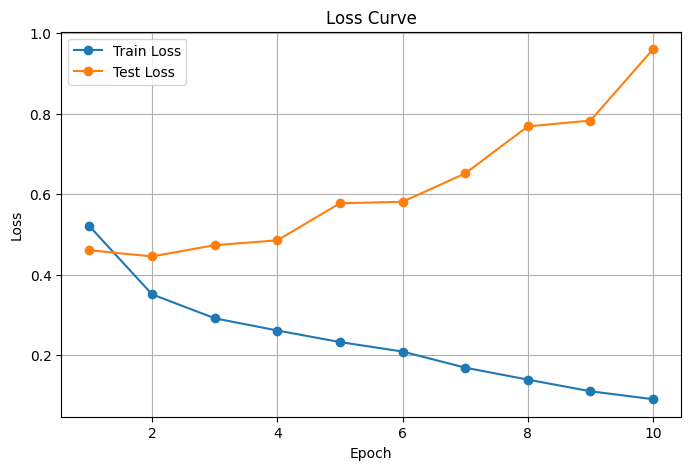

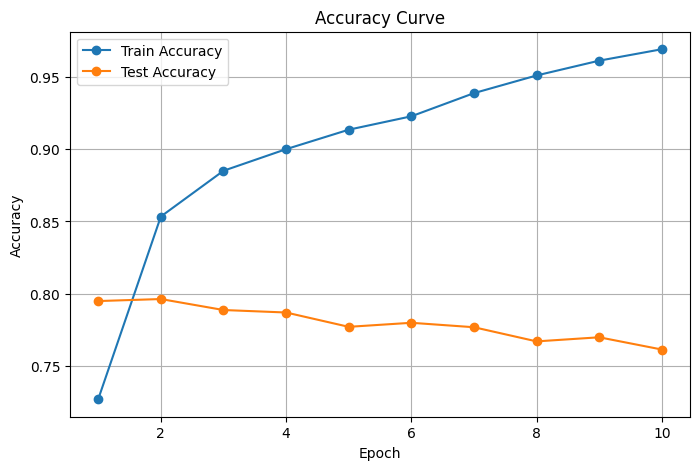

In [12]:
# x축에 사용할 epoch 번호를 생성합니다.
epochs_range = range(1, EPOCHS + 1)

# history에서 학습 손실값 리스트를 가져옵니다.
train_loss = history.history["loss"]

# history에서 평가 손실값 리스트를 가져옵니다.
test_loss = history.history["val_loss"]

# BinaryAccuracy 지표 이름은 TensorFlow 버전에 따라 binary_accuracy 또는 binary_accuracy_1처럼 달라질 수 있습니다.
# 따라서 history 키 중에서 accuracy가 포함된 이름을 찾아 사용합니다.
accuracy_keys = [key for key in history.history.keys() if "accuracy" in key and not key.startswith("val_")]

# 평가 정확도 키도 같은 방식으로 찾습니다.
val_accuracy_keys = [key for key in history.history.keys() if key.startswith("val_") and "accuracy" in key]

# 첫 번째 정확도 키를 학습 정확도 키로 사용합니다.
train_acc_key = accuracy_keys[0]

# 첫 번째 평가 정확도 키를 평가 정확도 키로 사용합니다.
test_acc_key = val_accuracy_keys[0]

# history에서 학습 정확도 리스트를 가져옵니다.
train_acc = history.history[train_acc_key]

# history에서 평가 정확도 리스트를 가져옵니다.
test_acc = history.history[test_acc_key]

# 손실 그래프를 그리기 위해 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# epoch별 학습 손실을 선 그래프로 그립니다.
plt.plot(epochs_range, train_loss, marker="o", label="Train Loss")

# epoch별 평가 손실을 선 그래프로 그립니다.
plt.plot(epochs_range, test_loss, marker="o", label="Test Loss")

# 그래프 제목을 설정합니다.
plt.title("Loss Curve")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

# 정확도 그래프를 그리기 위해 그래프 크기를 설정합니다.
plt.figure(figsize=(8, 5))

# epoch별 학습 정확도를 선 그래프로 그립니다.
plt.plot(epochs_range, train_acc, marker="o", label="Train Accuracy")

# epoch별 평가 정확도를 선 그래프로 그립니다.
plt.plot(epochs_range, test_acc, marker="o", label="Test Accuracy")

# 그래프 제목을 설정합니다.
plt.title("Accuracy Curve")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("Accuracy")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


## 11. 최종 평가

평가 데이터 전체에 대해 최종 손실, 정확도, F1 점수, 혼동행렬을 확인합니다.


In [13]:
# model.evaluate는 평가 데이터에 대한 손실값과 정확도를 계산합니다.
# 반환값은 compile에서 지정한 loss와 metrics 순서에 따라 나옵니다.
eval_results = model.evaluate(test_dataset, verbose=0)

# 첫 번째 반환값은 손실값입니다.
final_loss = eval_results[0]

# 두 번째 반환값은 BinaryAccuracy입니다.
final_acc = eval_results[1]

# 최종 평가 손실을 출력합니다.
print(f"최종 평가 손실: {final_loss:.4f}")

# 최종 평가 정확도를 출력합니다.
print(f"최종 평가 정확도: {final_acc * 100:.2f}%")


최종 평가 손실: 0.9597
최종 평가 정확도: 76.13%


In [14]:
# model.predict는 평가 입력 데이터에 대한 예측 확률을 계산합니다.
# 출력값은 긍정 클래스일 확률입니다.
final_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)

# 예측 확률을 1차원 배열로 변환합니다.
final_probs = final_probs.reshape(-1)

# 확률이 0.5 이상이면 긍정 1, 미만이면 부정 0으로 변환합니다.
final_preds = (final_probs >= 0.5).astype("int32")

# 실제 라벨도 정수형 1차원 배열로 변환합니다.
final_labels = y_test.astype("int32").reshape(-1)

# sklearn으로 정확도를 다시 계산합니다.
# model.evaluate 결과와 같은 의미이며, 직접 예측 배열을 확인하는 용도입니다.
sklearn_acc = accuracy_score(final_labels, final_preds)

# F1 점수를 계산합니다.
# F1은 정밀도와 재현율을 함께 고려하는 지표입니다.
f1 = f1_score(final_labels, final_preds, average="binary")

# 혼동행렬을 계산합니다.
# 행은 실제 라벨, 열은 예측 라벨을 의미합니다.
cm = confusion_matrix(final_labels, final_preds)

# sklearn으로 계산한 정확도를 출력합니다.
print(f"sklearn 기준 정확도: {sklearn_acc * 100:.2f}%")

# F1 점수를 출력합니다.
print(f"최종 F1 점수: {f1 * 100:.2f}%")

# 혼동행렬을 출력합니다.
print("\n혼동행렬:")
print(cm)

# 혼동행렬의 의미를 출력합니다.
print("\n혼동행렬 해석:")
print("[[실제 부정-예측 부정, 실제 부정-예측 긍정],")
print(" [실제 긍정-예측 부정, 실제 긍정-예측 긍정]]")


sklearn 기준 정확도: 76.13%
최종 F1 점수: 75.31%

혼동행렬:
[[9932 2568]
 [3399 9101]]

혼동행렬 해석:
[[실제 부정-예측 부정, 실제 부정-예측 긍정],
 [실제 긍정-예측 부정, 실제 긍정-예측 긍정]]


## 12. 혼동행렬 시각화

혼동행렬을 그림으로 보면 어떤 클래스를 잘 맞히고, 어떤 클래스를 많이 틀리는지 쉽게 확인할 수 있습니다.


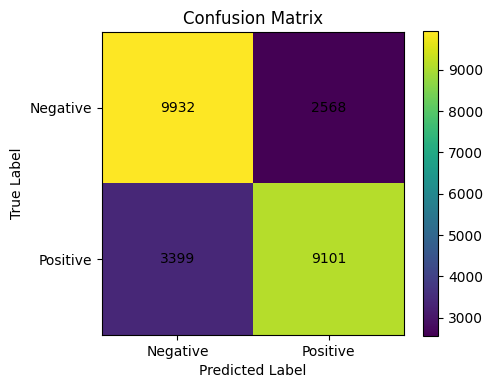

In [15]:
# 혼동행렬 그래프 크기를 설정합니다.
plt.figure(figsize=(5, 4))

# 혼동행렬을 이미지 형태로 표시합니다.
plt.imshow(cm, interpolation="nearest")

# 그래프 제목을 설정합니다.
plt.title("Confusion Matrix")

# 오른쪽에 색상 막대를 표시합니다.
plt.colorbar()

# x축과 y축에 표시할 클래스 이름을 정의합니다.
label_names = ["Negative", "Positive"]

# 클래스 위치 인덱스를 생성합니다.
tick_marks = np.arange(len(label_names))

# x축 눈금 이름을 설정합니다.
plt.xticks(tick_marks, label_names)

# y축 눈금 이름을 설정합니다.
plt.yticks(tick_marks, label_names)

# 혼동행렬 각 칸에 숫자를 표시합니다.
for i in range(cm.shape[0]):
    # 열 방향으로 반복합니다.
    for j in range(cm.shape[1]):
        # j는 x축 위치, i는 y축 위치입니다.
        # str(cm[i, j])는 해당 칸의 개수를 문자열로 바꾼 값입니다.
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

# y축 이름을 설정합니다.
plt.ylabel("True Label")

# x축 이름을 설정합니다.
plt.xlabel("Predicted Label")

# 그래프 요소가 겹치지 않도록 자동 정렬합니다.
plt.tight_layout()

# 그래프를 출력합니다.
plt.show()


## 13. 샘플 리뷰 예측 확인

평가 데이터 중 하나를 선택하여 실제 리뷰 단어, 정답 라벨, 모델 예측 결과를 확인합니다.


In [16]:
# 확인할 평가 데이터 인덱스를 지정합니다.
sample_idx = 5

# 선택한 샘플 리뷰를 가져옵니다.
# model.predict에 넣기 위해 배치 차원을 추가합니다.
sample_text = X_test[sample_idx:sample_idx + 1]

# 선택한 샘플의 정답 라벨을 가져옵니다.
sample_label = int(y_test[sample_idx])

# 모델이 샘플 리뷰에 대한 긍정 확률을 예측합니다.
sample_prob = model.predict(sample_text, verbose=0)[0, 0]

# 확률이 0.5 이상이면 1, 아니면 0으로 예측합니다.
sample_pred = 1 if sample_prob >= 0.5 else 0

# 샘플 리뷰를 단어로 복원합니다.
sample_review_text = decode_review(X_test[sample_idx], id_to_word)

# 샘플 리뷰와 결과를 출력합니다.
print("샘플 리뷰:")
print(sample_review_text)

# 정답 라벨을 출력합니다.
print("\n정답 라벨:", sample_label, "(0=부정, 1=긍정)")

# 모델이 계산한 긍정 확률을 출력합니다.
print(f"모델의 긍정 확률: {sample_prob:.4f}")

# 모델 예측 결과를 출력합니다.
print("모델 예측:", sample_pred, "(0=부정, 1=긍정)")


샘플 리뷰:
??? i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and

정답 라벨: 1 (0=부정, 1=긍정)
모델의 긍정 확률: 0.9485
모델 예측: 1 (0=부정, 1=긍정)


## 14. 직접 작성한 문장 예측 함수

새로운 영어 영화 리뷰 문장을 입력하면, IMDB 단어 사전을 이용해 숫자 시퀀스로 변환한 뒤 모델이 긍정/부정을 예측합니다.

단, 이 예제의 단어 전처리는 간단한 공백 분리 방식이므로 실제 서비스 수준의 자연어 전처리와는 차이가 있습니다.


In [21]:
# 직접 입력한 영어 문장을 모델 입력 형태로 변환하는 함수를 정의합니다.
def encode_custom_review(text, word_to_id, max_len):
    # 입력 문장을 소문자로 변환합니다.
    # IMDB 단어 사전은 대부분 소문자 기준으로 구성되어 있습니다.
    text = text.lower()

    # 마침표와 쉼표 같은 간단한 문장부호를 공백으로 바꿉니다.
    # 복잡한 전처리는 아니지만 기본 실습에서는 충분합니다.
    for punctuation in [".", ",", "!", "?", ":", ";", "(", ")", "\"", "'"]:
        text = text.replace(punctuation, " ")

    # 공백을 기준으로 문장을 단어 리스트로 나눕니다.
    words = text.split()

    # 단어들을 IMDB 단어 번호로 변환할 리스트를 만듭니다.
    encoded = []

    # 단어를 하나씩 반복합니다.
    for word in words:
        # IMDB 데이터셋은 실제 단어 번호에 특수 토큰 오프셋 3을 더해 사용하는 구조입니다.
        token_id = word_to_id.get(word, 2) + 3

        # NUM_WORDS보다 작은 번호만 사용합니다.
        # 학습 때 상위 NUM_WORDS개 단어만 사용했기 때문입니다.
        if token_id < NUM_WORDS:
            encoded.append(token_id)
        else:
            # 사전에 없거나 너무 드문 단어는 2번 토큰으로 처리합니다.
            # 일반적으로 2는 unknown에 가까운 의미로 사용됩니다.
            encoded.append(2)

    # pad_sequences로 길이를 max_len에 맞춥니다.
    encoded_padded = pad_sequences(
        [encoded],              # pad_sequences는 여러 문장 목록을 입력으로 받으므로 리스트로 감쌉니다.
        maxlen=max_len,         # 모델 입력 길이와 같은 길이로 맞춥니다.
        truncating="post",      # 긴 문장은 뒤쪽을 자릅니다.
        padding="post"          # 짧은 문장은 뒤쪽에 0을 채웁니다.
    )

    # TensorFlow Embedding 계층 입력에 적합하도록 int32로 변환합니다.
    return encoded_padded.astype("int32")

# 직접 예측할 긍정 리뷰 예시입니다.
custom_review = "This movie was very good and I really enjoyed the story"

# 직접 작성한 문장을 숫자 시퀀스로 변환합니다.
custom_encoded = encode_custom_review(custom_review, word_to_id, MAX_LEN)

# 모델이 직접 작성한 문장의 긍정 확률을 예측합니다.
custom_prob = model.predict(custom_encoded, verbose=0)[0, 0]

# 0.5 기준으로 최종 클래스를 결정합니다.
custom_pred = 1 if custom_prob >= 0.5 else 0

# 입력 문장을 출력합니다.
print("입력 문장:", custom_review)

# 긍정 확률을 출력합니다.
print(f"긍정 확률: {custom_prob:.4f}")

# 최종 예측 결과를 출력합니다.
print("예측 결과:", custom_pred, "(0=부정, 1=긍정)")


입력 문장: This movie was very good and I really enjoyed the story
긍정 확률: 0.9859
예측 결과: 1 (0=부정, 1=긍정)


## 15. 모델 저장과 불러오기

TensorFlow/Keras에서는 학습된 모델을 `.keras` 형식으로 저장할 수 있습니다.

이 형식은 모델 구조, 가중치, 컴파일 정보를 함께 저장할 수 있어 나중에 다시 불러와 예측에 사용할 수 있습니다.


In [22]:
# 모델을 저장할 파일 이름을 지정합니다.
# .keras는 TensorFlow/Keras에서 권장하는 최신 모델 저장 형식입니다.
MODEL_PATH = "imdb_sentiment_lstm_adamw.keras"

# 학습된 모델 전체를 저장합니다.
# 모델 구조와 학습된 가중치가 함께 저장됩니다.
model.save(MODEL_PATH)

# 모델 저장 완료 메시지를 출력합니다.
print("모델 저장 완료:", MODEL_PATH)

# 저장된 모델을 다시 불러옵니다.
# custom_objects 없이도 기본 Keras 계층과 AdamW는 일반적으로 정상적으로 불러올 수 있습니다.
loaded_model = keras.models.load_model(MODEL_PATH)

# 모델 불러오기 완료 메시지를 출력합니다.
print("모델 불러오기 완료")

# 불러온 모델로 샘플 하나를 다시 예측하여 정상 작동 여부를 확인합니다.
loaded_sample_prob = loaded_model.predict(sample_text, verbose=0)[0, 0]

# 불러온 모델의 예측 확률을 출력합니다.
print(f"불러온 모델의 샘플 긍정 확률: {loaded_sample_prob:.4f}")


모델 저장 완료: imdb_sentiment_lstm_adamw.keras
모델 불러오기 완료
불러온 모델의 샘플 긍정 확률: 0.9485


## 16. 성능 개선 실험 방향

정확도와 F1 점수를 높이려면 다음 항목을 실험할 수 있습니다.

1. `MAX_LEN`을 120 또는 200으로 늘려 더 긴 리뷰 정보를 사용합니다.
2. `EMBED_DIM`을 64 또는 128로 늘립니다.
3. `HIDDEN_DIM`을 128 또는 256으로 늘립니다.
4. LSTM 계층을 2개 이상 쌓아 더 깊은 모델을 만듭니다.
5. `Bidirectional(layers.LSTM(...))`을 사용하여 양방향 LSTM을 적용합니다.
6. 학습률을 `0.0005`, `0.0003` 등으로 낮춰 봅니다.
7. 에포크 수를 늘리되 평가 손실이 증가하면 과적합을 의심합니다.
8. `EarlyStopping` 콜백을 사용해 평가 손실이 더 이상 좋아지지 않을 때 자동으로 학습을 멈춥니다.
